In [10]:
import pandas as pd
import os

folder_path = r'D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_case-label'

csv_file = [f for f in os.listdir(folder_path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(folder_path, csv_file))
print(df.head())
print(df.info())



import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch CUDA build:", torch.version.cuda)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


           patientID_studyID  any  epidural  intraparenchymal  \
0  ID_00526c11_ID_d6296de728    1         0                 1   
1  ID_00c33d73_ID_c67f7e4103    1         0                 1   
2  ID_018b83e7_ID_3331f55013    1         0                 1   
3  ID_020d770a_ID_e2b1917b29    1         0                 0   
4  ID_02a8f616_ID_457a9add67    1         0                 1   

   intraventricular  subarachnoid  subdural  
0                 0             0         0  
1                 1             0         0  
2                 0             1         1  
3                 0             0         1  
4                 1             1         1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patientID_studyID  577 non-null    object
 1   any                577 non-null    int64 
 2   epidural           577 non-null    i

In [11]:
import os
import glob
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from monai.networks.nets import resnet18
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRangePercentilesd,
    Resized,
    EnsureTyped,
    CropForegroundd
)
from monai.data import Dataset
from sklearn.model_selection import train_test_split
from torch.cuda.amp import autocast, GradScaler

# ---------------------------------------------------------
# 1. SETUP & 8GB VRAM HYPERPARAMETERS
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGE_DIR = r"D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_case-label"
# Keep batch size very small to fit 8GB VRAM
BATCH_SIZE = 2 
# Accumulate gradients to simulate a larger batch size of 8 (2 * 4)
ACCUMULATION_STEPS = 4 
EPOCHS = 50
LEARNING_RATE = 1e-4

# Load your dataframe
df = pd.read_csv(r"D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_case-label\case-wise_annotation.csv")
target_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']









Using device: cuda


In [12]:

# ---------------------------------------------------------
# 2. MATCH ALL IMAGES (HEALTHY AND HEMORRHAGE)
# ---------------------------------------------------------
data_dicts = []
# Create a dictionary from the dataframe for fast lookup
# Keys are patientID_studyID, Values are a dict of the 5 hemorrhage flags
df_dict = df.set_index('patientID_studyID')[target_cols].to_dict('index')

# Get ALL .nii.gz files in the folder
all_files = glob.glob(os.path.join(IMAGE_DIR, "*.nii.gz"))

for img_path in all_files:
    # Extract the patient ID from the file name (Adjust if your naming is different)
    file_name = os.path.basename(img_path)
    patient_id = file_name.replace(".nii.gz", "") 
    
    if patient_id in df_dict:
        # It's a hemorrhage case! Extract the 5 labels
        labels = np.array(list(df_dict[patient_id].values()), dtype=np.float32)
    else:
        # It's a HEALTHY case! Assign all zeros
        labels = np.zeros(len(target_cols), dtype=np.float32)
        
    data_dicts.append({
        "image": img_path,
        "label": labels
    })

print(f"Total cases found: {len(data_dicts)}") # This should now read ~1980

train_files, val_files = train_test_split(data_dicts, test_size=0.2, random_state=42)

Total cases found: 1980


In [13]:

# ---------------------------------------------------------
# 3. MEMORY-OPTIMIZED TRANSFORMS
# ---------------------------------------------------------
# Reduced spatial_size to (96, 96, 96) to guarantee it fits on 8GB VRAM
train_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRangePercentilesd(keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(96, 96, 96)), 
    EnsureTyped(keys=["image", "label"], device=device)
])


# train_transforms = Compose([
#     LoadImaged(keys=["image"]),
#     EnsureChannelFirstd(keys=["image"]),
#     Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
#     ScaleIntensityRangePercentilesd(keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True),
    
#     # NEW: Automatically crops away the empty black background around the brain
#     CropForegroundd(keys=["image"], source_key="image"),
    
#     # You can safely increase this to 128x128x128 if the school PC has 12GB+ VRAM
#     Resized(keys=["image"], spatial_size=(128, 128, 128)), 
#     EnsureTyped(keys=["image", "label"], device=device)
# ])


val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRangePercentilesd(keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(96, 96, 96)),
    EnsureTyped(keys=["image", "label"], device=device)
])

train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


In [14]:



# ---------------------------------------------------------
# 4. INITIALIZE MODEL & MIXED PRECISION SCALER
# ---------------------------------------------------------
model = resnet18(spatial_dims=3, n_input_channels=1, num_classes=len(target_cols)).to(device)
loss_function = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Mixed Precision Scaler for RTX cards
scaler = GradScaler() 

C:\Users\ulise\AppData\Local\Temp\ipykernel_29412\977004521.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [15]:


# ---------------------------------------------------------
# 5. VRAM-EFFICIENT TRAINING LOOP
# ---------------------------------------------------------
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"--- Epoch {epoch + 1}/{EPOCHS} ---")
    
    model.train()
    epoch_loss = 0
    optimizer.zero_grad() # Move zero_grad outside the inner loop for accumulation
    
    for step, batch_data in enumerate(train_loader):
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        
        # Run forward pass in 16-bit mixed precision
        with autocast():
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            # Normalize loss for gradient accumulation
            loss = loss / ACCUMULATION_STEPS 
        
        # Scale loss and run backward pass
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * ACCUMULATION_STEPS 
        
        # Only step optimizer every ACCUMULATION_STEPS
        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
    train_loss = epoch_loss / len(train_loader)
    print(f"Train Loss: {train_loss:.4f}")
    
    # VALIDATION (No gradients needed, very light on VRAM)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_data in val_loader:
            inputs, labels = val_data["image"].to(device), val_data["label"].to(device)
            # We can use autocast during inference too
            with autocast():
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    print(f"Validation Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_resnet3d_8gb_vram.pth")
        print("--> Saved new best model!")


--- Epoch 1/50 ---


C:\Users\ulise\AppData\Local\Temp\ipykernel_29412\552998538.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 0.3413


C:\Users\ulise\AppData\Local\Temp\ipykernel_29412\552998538.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validation Loss: 0.3294
--> Saved new best model!
--- Epoch 2/50 ---
Train Loss: 0.3213
Validation Loss: 0.3081
--> Saved new best model!
--- Epoch 3/50 ---
Train Loss: 0.3116
Validation Loss: 0.3060
--> Saved new best model!
--- Epoch 4/50 ---
Train Loss: 0.3057
Validation Loss: 0.2963
--> Saved new best model!
--- Epoch 5/50 ---
Train Loss: 0.3018
Validation Loss: 0.3041
--- Epoch 6/50 ---


KeyboardInterrupt: 

C:\Users\ulise\AppData\Local\Temp\ipykernel_33764\161438384.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_resnet3d_8gb_vram.pth

Generating CAM for subdural...
Saved CAM heatmap to gradcam_output.nii.gz


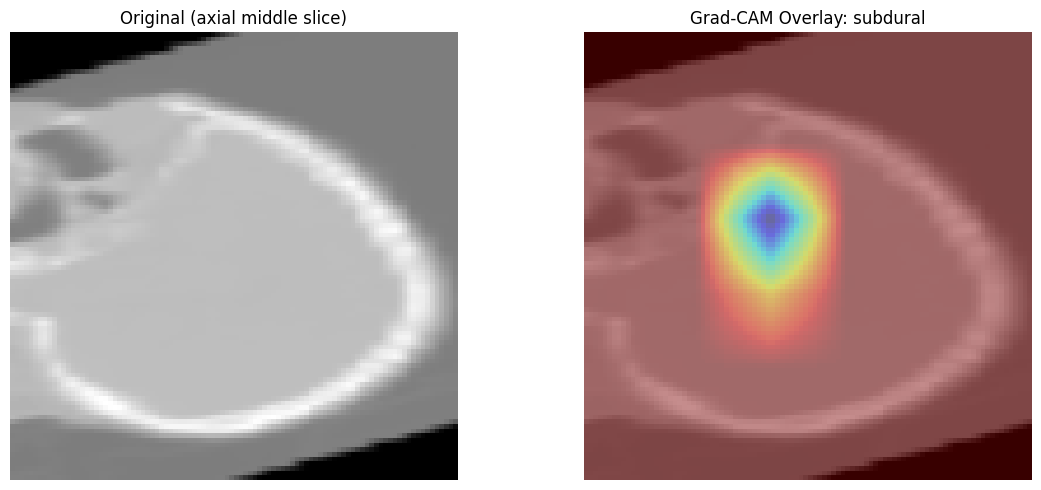

In [ ]:
import os
import torch
import numpy as np
import nibabel as nib
import SimpleITK as sitk
from monai.networks.nets import resnet18
from monai.visualize import GradCAM
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRangePercentilesd,
    CropForegroundd,
    Resized,
    EnsureTyped
)

# ---------------------------------------------------------
# 1. SETUP & LOAD MODEL
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# Initialize the exact same model architecture
model = resnet18(spatial_dims=3, n_input_channels=1, num_classes=len(target_cols)).to(device)

# Load your saved weights
model.load_state_dict(torch.load("best_resnet3d_8gb_vram.pth", map_location=device))
model.eval() # MUST be in eval mode for inference

# ---------------------------------------------------------
# 2. INITIALIZE GRAD-CAM
# ---------------------------------------------------------
# In MONAI's resnet18, the final convolutional layer before pooling is 'layer4'
# GradCAM needs to hook into this specific layer to get the spatial heatmaps.
cam_extractor = GradCAM(nn_module=model, target_layers="layer4")

# ---------------------------------------------------------
# 3. PREPARE A TEST IMAGE
# ---------------------------------------------------------
# Replace this with the path to a specific scan you know has a hemorrhage
test_image_path = r"D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_case-label\ID_0a01a6c4_ID_f361ca3063.nii.gz"

# We must apply the exact same transforms used during training
val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRangePercentilesd(keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image"], source_key="image"),
    Resized(keys=["image"], spatial_size=(96, 96, 96)),
    EnsureTyped(keys=["image"], device=device)
])

# Process the single image
data_dict = {"image": test_image_path}
processed_data = val_transforms(data_dict)

# Add batch dimension: shape becomes [1, 1, 96, 96, 96]
input_tensor = processed_data["image"].unsqueeze(0)

# ---------------------------------------------------------
# 4. GENERATE AND SAVE THE HEATMAP
# ---------------------------------------------------------
# Let's say we want to see where the model thinks the 'subdural' hemorrhage is.
# Look at target_cols above: 'subdural' is index 4.
class_index_to_visualize = 4 

print(f"Generating CAM for {target_cols[class_index_to_visualize]}...")

# Generate the 3D heatmap
# Note: GradCAM requires gradients, even in eval mode, so we DO NOT use torch.no_grad() here
heatmap = cam_extractor(x=input_tensor, class_idx=class_index_to_visualize)

# The heatmap is a tensor of shape [1, 1, 96, 96, 96]. 
# Convert it to a numpy array and remove batch/channel dimensions
heatmap_np = heatmap.squeeze().cpu().detach().numpy()

# Normalize the heatmap to [0, 1] for visualization
heatmap_np = (heatmap_np - np.min(heatmap_np)) / (np.max(heatmap_np) - np.min(heatmap_np) + 1e-8)

# Convert to SimpleITK image to save as .nii.gz
sitk_heatmap = sitk.GetImageFromArray(heatmap_np)

# Get the original image to copy its geometry (so they overlay perfectly in ITK-SNAP)
original_img = sitk.ReadImage(test_image_path)
# Note: Because we resized to 96x96x96, the geometry won't match perfectly without resampling back up,
# but for a quick visual check, saving the raw 96x96x96 array is usually sufficient.

output_file = "gradcam_output.nii.gz"
sitk.WriteImage(sitk_heatmap, output_file)

print(f"Saved CAM heatmap to {output_file}")


import matplotlib.pyplot as plt

# Convert tensors to NumPy
img_np = input_tensor.squeeze().detach().cpu().numpy()   # [D, H, W]
cam_np = heatmap.squeeze().detach().cpu().numpy()        # [D, H, W]

# Normalize CAM for display
cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

# Middle axial slice
z = img_np.shape[0] // 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# plt.imshow(img_np[z], cmap="gray")
img = nib.load(test_image_path).get_fdata()
img = img[:, :, img.shape[2] // 2]  # Get the middle axial slice from the original image
plt.imshow(img)
plt.title("Original (axial middle slice)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_np[z], cmap="gray")
plt.imshow(cam_np[z], cmap="jet", alpha=0.45)
plt.title(f"Grad-CAM Overlay: {target_cols[class_index_to_visualize]}")
plt.axis("off")

plt.tight_layout()
plt.show()